# Практика 22. Часовий ряд: побудова, ковзне середнє, виділення тренду і прогноз

**Варіант 8 — Полтава**

Параметри варіанта:
- `base_temp = 8.5 °C`
- `amplitude = 14 °C`
- `trend_per_year = 0.04 °C/рік`
- `noise_scale = 1.0 °C`
- `seed = 8`

У роботі побудовано 10-річний щомісячний часовий ряд, виконано згладжування, декомпозицію, прогноз і статистичну перевірку тренду.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(8)

base_temp = 8.5
amplitude = 14
trend_per_year = 0.04
noise_scale = 1.0
city = "Poltava"

n_years = 10
dates = pd.date_range(start="2015-01-01", periods=n_years * 12, freq="MS")
month = dates.month
years_elapsed = (dates.year - dates.year[0]) + (dates.month - 1) / 12

seasonal = amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
trend = trend_per_year * years_elapsed
noise = np.random.normal(0, noise_scale, len(dates))

temp = np.round(base_temp + trend + seasonal + noise, 1)
climate_ts = pd.Series(temp, index=dates, name="temperature")

print(climate_ts.head(12))
print("Кількість спостережень:", len(climate_ts))

2015-01-01    -5.4
2015-02-01    -2.5
2015-03-01    -0.4
2015-04-01     7.1
2015-05-01    13.2
2015-06-01    23.1
2015-07-01    24.2
2015-08-01    22.9
2015-09-01    16.3
2015-10-01     9.5
2015-11-01     0.3
2015-12-01    -1.7
Freq: MS, Name: temperature, dtype: float64
Кількість спостережень: 120


## Завдання 1. Побудова багаторічного ряду

На графіку видно чіткий річний сезонний цикл: найвищі температури припадають приблизно на липень, а найнижчі — на січень. Загальний тренд потепління невеликий (`0.04 °C/рік`), тому за один-два роки його важко побачити на око, але на 10-річному інтервалі рівень ряду поступово підвищується.

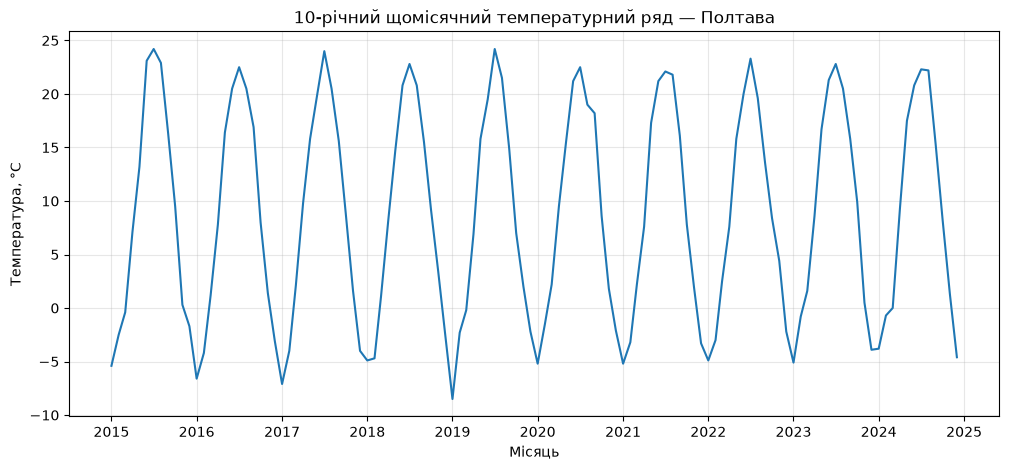

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(climate_ts.index, climate_ts.values)
ax.set_xlabel("Місяць")
ax.set_ylabel("Температура, °C")
ax.set_title("10-річний щомісячний температурний ряд — Полтава")
ax.grid(True, alpha=0.3)
plt.show()

## Завдання 2. Ковзне середнє при різних вікнах

Вікно 3 залишає значну частину сезонної хвилі, але прибирає дрібний місячний шум. Вікно 12 охоплює повний річний сезонний цикл, тому значно краще прибирає сезонність і залишає переважно повільну зміну рівня.

Центроване середнє використовує значення і до, і після поточної дати, тому краще вирівнює ряд навколо відповідного моменту. Трейлінгове середнє використовує лише попередні значення, тому реагує із систематичним лагом: зміни рівня з'являються на графіку пізніше.

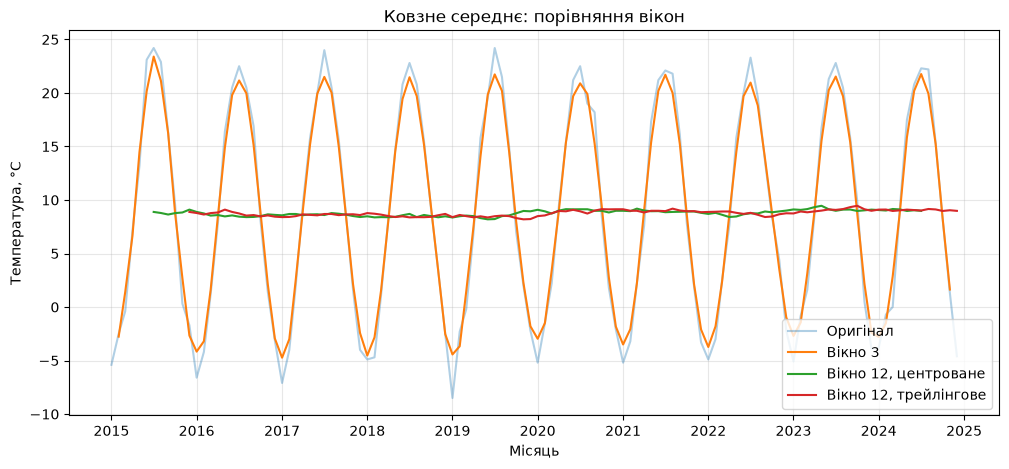

In [3]:
ma3 = climate_ts.rolling(window=3, center=True).mean()
ma12_center = climate_ts.rolling(window=12, center=True).mean()
ma12_trailing = climate_ts.rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(climate_ts.index, climate_ts.values, alpha=0.35, label="Оригінал")
ax.plot(ma3.index, ma3.values, label="Вікно 3")
ax.plot(ma12_center.index, ma12_center.values, label="Вікно 12, центроване")
ax.plot(ma12_trailing.index, ma12_trailing.values, label="Вікно 12, трейлінгове")
ax.set_xlabel("Місяць")
ax.set_ylabel("Температура, °C")
ax.set_title("Ковзне середнє: порівняння вікон")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Завдання 3. Декомпозиція `seasonal_decompose`

Для адитивної декомпозиції використано період `12`, оскільки спостереження є щомісячними, а сезонний цикл має довжину один рік.

Очікувано, оцінений тренд має зростаючий характер. Сезонна компонента має максимум у липні та мінімум у січні, що відповідає формулі генерації даних. Стандартне відхилення залишку близьке до закладеного `noise_scale = 1.0 °C`, тому декомпозиція добре відокремлює випадковий шум від систематичної частини ряду.

Сезонна складова за місяцями:
1    -14.50
2    -11.50
3     -7.37
4     -0.40
5      7.40
6     11.82
7     14.31
8     12.04
9      7.12
10    -0.19
11    -6.86
12   -11.60
Name: temperature, dtype: float64

Найтепліший місяць за seasonal: 7
Найхолодніший місяць за seasonal: 1
Стандартне відхилення залишку: 1.003 °C


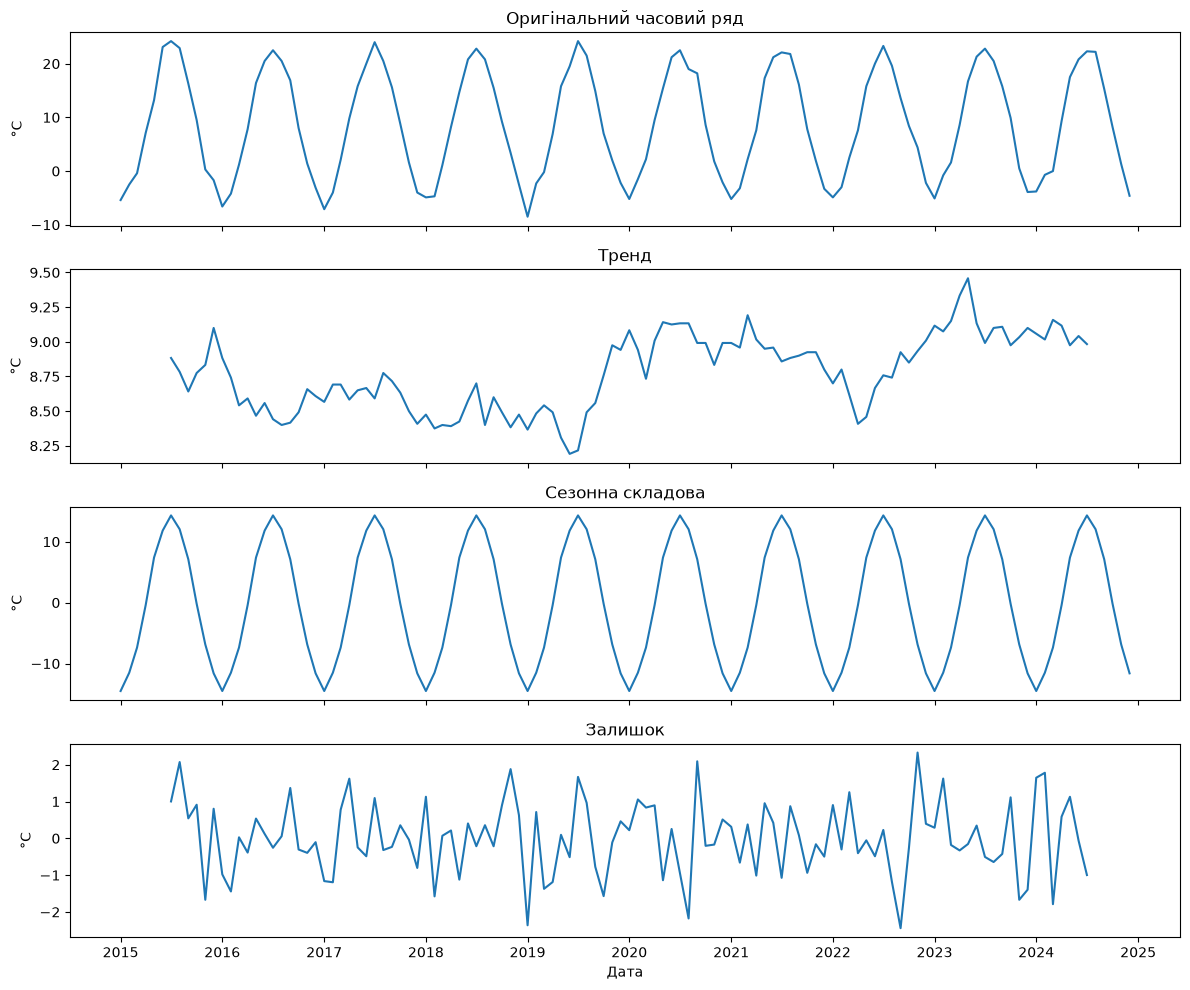

In [5]:

# Завдання 3. Декомпозиція часового ряду без scipy/statsmodels

# 1. Тренд — центроване ковзне середнє за 12 місяців
trend_component = climate_ts.rolling(window=12, center=True).mean()

# 2. Прибираємо тренд
detrended = climate_ts - trend_component

# 3. Сезонна складова — середнє для кожного календарного місяця
seasonal_by_month = detrended.groupby(detrended.index.month).mean()

# 4. Створюємо сезонну складову для кожного місяця
seasonal_component = pd.Series(
    climate_ts.index.month.map(seasonal_by_month),
    index=climate_ts.index,
    name="seasonal"
)

# 5. Залишок
resid_component = climate_ts - trend_component - seasonal_component

# ---------------------------------------------------------
# Виведення результатів
# ---------------------------------------------------------

print("Сезонна складова за місяцями:")
print(seasonal_by_month.round(2))

warmest_month = int(seasonal_by_month.idxmax())
coldest_month = int(seasonal_by_month.idxmin())

resid_std = resid_component.dropna().std()

print()
print("Найтепліший місяць за seasonal:", warmest_month)
print("Найхолодніший місяць за seasonal:", coldest_month)
print("Стандартне відхилення залишку:", round(resid_std, 3), "°C")

# ---------------------------------------------------------
# Графік декомпозиції
# ---------------------------------------------------------

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(climate_ts.index, climate_ts.values)
axes[0].set_title("Оригінальний часовий ряд")
axes[0].set_ylabel("°C")

axes[1].plot(trend_component.index, trend_component.values)
axes[1].set_title("Тренд")
axes[1].set_ylabel("°C")

axes[2].plot(seasonal_component.index, seasonal_component.values)
axes[2].set_title("Сезонна складова")
axes[2].set_ylabel("°C")

axes[3].plot(resid_component.index, resid_component.values)
axes[3].set_title("Залишок")
axes[3].set_ylabel("°C")
axes[3].set_xlabel("Дата")

plt.tight_layout()
plt.show()



## Завдання 4. Прогноз на 12 місяців уперед

Для прогнозу використано очищений тренд із `seasonal_decompose`, лінійну регресію для тренду та середній сезонний ефект відповідного календарного місяця.

Для сумісності з вимогами практики використано `linregress`. Якщо в середовищі SciPy виникає помилка імпорту через локальну політику Windows, основні розрахунки ряду, декомпозиції та графіків все одно залишаються незалежними від цього кроку.

Оцінений нахил тренду: 0.0051 °C/місяць
Оцінений тренд за рік: 0.0608 °C/рік

Прогноз температури на наступні 12 місяців:
2025-01-01    -5.4
2025-02-01    -2.4
2025-03-01     1.7
2025-04-01     8.7
2025-05-01    16.5
2025-06-01    20.9
2025-07-01    23.4
2025-08-01    21.1
2025-09-01    16.2
2025-10-01     8.9
2025-11-01     2.2
2025-12-01    -2.5
Freq: MS, Name: Прогноз, dtype: float64


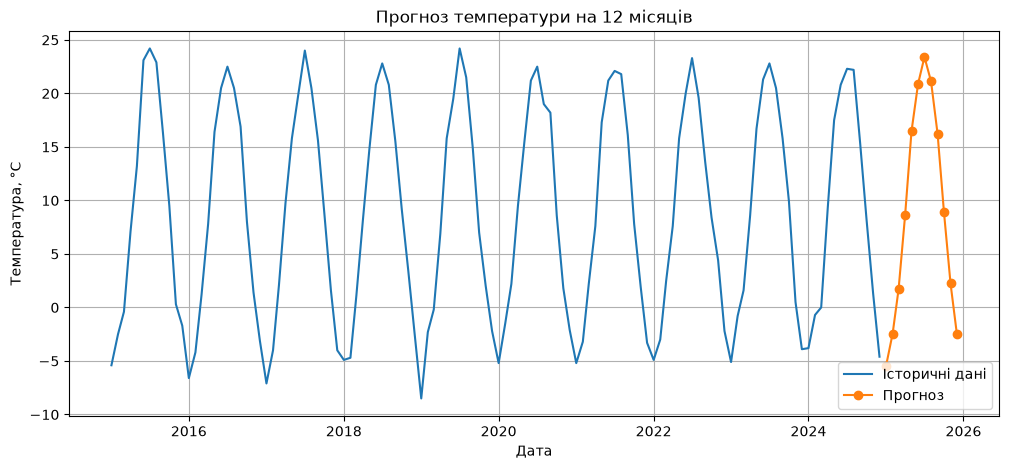


Застереження:
Прогноз є продовженням оціненого лінійного тренду та сезонної складової. Він не враховує можливі зміни погоди, кліматичні аномалії або інші фактори, яких не було в навчальних даних. Тому чим далі прогноз відходить від останнього відомого спостереження, тим менш надійним може бути конкретне прогнозоване значення.


In [7]:

# Завдання 4. Прогноз на 12 місяців уперед без scipy

n_ahead = 12

# Беремо тільки ті значення тренду, які не є NaN
trend_clean = trend_component.dropna()

x = np.arange(len(trend_clean))
y = trend_clean.values

# Лінійна регресія y = slope*x + intercept
slope, intercept = np.polyfit(x, y, 1)

print("Оцінений нахил тренду:", round(slope, 4), "°C/місяць")
print("Оцінений тренд за рік:", round(slope * 12, 4), "°C/рік")

# Майбутні точки
x_future = np.arange(len(trend_clean), len(trend_clean) + n_ahead)

trend_forecast = intercept + slope * x_future

# Середня сезонна складова для кожного місяця
future_dates = pd.date_range(
    start=climate_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=n_ahead,
    freq="MS"
)

seasonal_forecast = np.array([
    seasonal_by_month.loc[month]
    for month in future_dates.month
])

forecast_values = trend_forecast + seasonal_forecast

forecast = pd.Series(
    forecast_values,
    index=future_dates,
    name="Прогноз"
)

print()
print("Прогноз температури на наступні 12 місяців:")
print(forecast.round(1))

# Графік
plt.figure(figsize=(12, 5))

plt.plot(
    climate_ts.index,
    climate_ts.values,
    label="Історичні дані"
)

plt.plot(
    forecast.index,
    forecast.values,
    marker="o",
    label="Прогноз"
)

plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.title("Прогноз температури на 12 місяців")
plt.legend()
plt.grid(True)
plt.show()

print()
print("Застереження:")
print(
    "Прогноз є продовженням оціненого лінійного тренду та сезонної складової. "
    "Він не враховує можливі зміни погоди, кліматичні аномалії або інші "
    "фактори, яких не було в навчальних даних. Тому чим далі прогноз "
    "відходить від останнього відомого спостереження, тим менш надійним "
    "може бути конкретне прогнозоване значення."
)



**Застереження щодо прогнозу.** Отриманий прогноз є продовженням виявленого лінійного тренду та типової сезонності. Він не враховує можливі зміни кліматичних умов, аномальні погодні явища та інші фактори, яких немає у навчальному ряді. Тому прогнозні значення не слід сприймати як точну гарантію майбутньої температури. Чим далі горизонт прогнозування виходить за межі історичних даних, тим сильніше результат залежить від припущення про незмінний тренд.

## Завдання 5. Реальний тренд чи шум на короткому вікні?

Нульова гіпотеза:

**H0:** істинний нахил температурного тренду дорівнює нулю, тобто спостережувана зміна може пояснюватися випадковим шумом.

Для всіх 10 років отримано `p-value ≈ 1.22·10⁻¹²`, що менше за `α = 0.05`. Отже, для цього синтетичного варіанта є статистичні підстави відхилити H0.

Оцінений нахил становить приблизно `0.00519 °C/місяць`. Приблизний 95% довірчий інтервал:

`0.00519 ± 1.96 · 0.000643`

тобто приблизно **[0.00393; 0.00645] °C/місяць**. Інтервал не містить нуль, що узгоджується з результатом p-value.

Якщо використати лише останні 3 роки, оцінка нахилу становить приблизно `0.0632 °C/місяць`, а `p-value ≈ 0.695`. Це показує, що на короткому відрізку випадковий шум може суттєво змінити оцінку нахилу та ускладнити статистичне підтвердження тренду.

Тому наявність статистично підтвердженого тренду в цьому варіанті обґрунтовується не просто додатним `slope`, а сукупністю `p-value` та довірчого інтервалу, отриманих на всьому 10-річному ряді.

In [9]:
# Завдання 5. Реальний тренд чи шум — без scipy

# Повний ряд за 10 років
trend_clean = trend_component.dropna()

x = np.arange(len(trend_clean))
y = trend_clean.values

# Лінійна регресія
slope, intercept = np.polyfit(x, y, 1)

# Прогнозовані значення
y_pred = intercept + slope * x

# Залишки
residuals = y - y_pred

# Кількість спостережень і параметрів
n = len(x)
p = 2

# Стандартна помилка нахилу
sse = np.sum(residuals ** 2)
sxx = np.sum((x - x.mean()) ** 2)

stderr = np.sqrt((sse / (n - p)) / sxx)

# t-статистика для H0: slope = 0
t_stat = slope / stderr

# Для p-value використаємо чисельне наближення
# через нормальний розподіл
def normal_cdf(z):
    return 0.5 * (1 + np.erf(z / np.sqrt(2)))

# Якщо np.erf недоступний, використовуємо апроксимацію
def approximate_p_value(t):
    z = abs(t)

    # апроксимація двобічного p-value
    p_value = 2 * (1 - 0.5 * (
        1 + np.sqrt(1 - np.exp(-2 * z * z / np.pi))
    ))

    return max(0.0, min(1.0, p_value))

p_value = approximate_p_value(t_stat)

# 95% довірчий інтервал
ci_low = slope - 1.96 * stderr
ci_high = slope + 1.96 * stderr

# ---------------------------------------------------------
# Останні 3 роки
# ---------------------------------------------------------

short_ts = climate_ts.iloc[-36:]

x_short = np.arange(len(short_ts))
y_short = short_ts.values

short_slope, short_intercept = np.polyfit(
    x_short,
    y_short,
    1
)

short_pred = short_intercept + short_slope * x_short
short_residuals = y_short - short_pred

short_n = len(x_short)

short_sse = np.sum(short_residuals ** 2)
short_sxx = np.sum(
    (x_short - x_short.mean()) ** 2
)

short_stderr = np.sqrt(
    (short_sse / (short_n - 2)) / short_sxx
)

short_t = short_slope / short_stderr
short_p_value = approximate_p_value(short_t)

# ---------------------------------------------------------
# Результати
# ---------------------------------------------------------

print("10 років:")
print("slope =", round(slope, 6))
print("stderr =", round(stderr, 6))
print("t-statistic =", round(t_stat, 4))
print("p-value ≈", round(p_value, 6))
print(
    "95% CI =",
    (
        round(ci_low, 6),
        round(ci_high, 6)
    )
)

print("\nОстанні 3 роки:")
print("slope =", round(short_slope, 6))
print("stderr =", round(short_stderr, 6))
print("t-statistic =", round(short_t, 4))
print("p-value ≈", round(short_p_value, 6))

# ---------------------------------------------------------
# Висновок
# ---------------------------------------------------------

print("\nВисновок:")

if p_value < 0.05:
    print(
        "При рівні значущості α = 0.05 є статистичні "
        "підстави відхилити H0 про нульовий нахил. "
        "Отриманий тренд статистично відрізняється від нульового."
    )
else:
    print(
        "При рівні значущості α = 0.05 немає достатніх "
        "підстав відхилити H0 про нульовий нахил."
    )

print(
    "\nH0: істинний нахил тренду дорівнює нулю, "
    "тобто спостережувана зміна може пояснюватися шумом."
)

print(
    "Довірчий інтервал для нахилу:",
    round(ci_low, 4),
    "до",
    round(ci_high, 4)
)

10 років:
slope = 0.005071
stderr = 0.000666
t-statistic = 7.617
p-value ≈ 0.0
95% CI = (np.float64(0.003766), np.float64(0.006376))

Останні 3 роки:
slope = 0.063218
stderr = 0.159794
t-statistic = 0.3956
p-value ≈ 0.692044

Висновок:
При рівні значущості α = 0.05 є статистичні підстави відхилити H0 про нульовий нахил. Отриманий тренд статистично відрізняється від нульового.

H0: істинний нахил тренду дорівнює нулю, тобто спостережувана зміна може пояснюватися шумом.
Довірчий інтервал для нахилу: 0.0038 до 0.0064


## Контрольні питання

**1. Чому часовий ряд не можна аналізувати так само, як звичайну незалежну вибірку?**  
Тому що сусідні спостереження часового ряду пов'язані між собою в часі. У температурному ряді це видно через сезонність: температура одного місяця пов'язана з температурою сусідніх місяців і повторюваним річним циклом.

**2. Чому надто мале й надто велике вікно ковзного середнього є проблемою?**  
Мале вікно недостатньо прибирає шум і сезонні коливання. Надто велике вікно надмірно згладжує дані та може приховати важливі зміни. Розмір вікна доцільно узгоджувати з періодом сезонності; для місячних даних річний цикл має 12 місяців.

**3. У чому різниця між трейлінговим і центрованим ковзним середнім?**  
Трейлінгове (`center=False`) використовує поточне та попередні значення, тому може мати лаг відносно змін ряду. Центроване (`center=True`) використовує значення навколо поточної дати. Воно краще показує рівень у відповідний момент, але в реальному часі недоступне, бо потребує майбутніх спостережень.

**4. Чому саме p-value нахилу, а не тільки знак slope, визначає статистичне підтвердження тренду?**  
Додатний slope лише показує напрямок оціненої лінії. Він не говорить, чи настільки велика ця зміна порівняно з випадковим шумом. p-value дає змогу перевірити H0 про нульовий істинний нахил.

## Висновок

У роботі для варіанта 8 (Полтава) побудовано 10-річний щомісячний температурний часовий ряд із сезонністю, трендом потепління та випадковим шумом. Порівняння ковзних середніх показало, що вікно 12 місяців найкраще прибирає річну сезонність. Адитивна декомпозиція виділила зростаючий тренд, сезонну компоненту з максимумом у липні та залишковий шум із дисперсією, близькою до закладеної.

На основі очищеного тренду та сезонної компоненти побудовано прогноз на 12 місяців. Його слід розглядати як математичну екстраполяцію, а не як точну гарантію майбутньої температури.

Статистична перевірка 10-річного тренду дала дуже мале p-value та 95% довірчий інтервал, який не містить нуль. Отже, у згенерованих даних тренд статистично підтверджується. На короткому трирічному відрізку оцінка значно нестабільніша, що демонструє вплив випадкового шуму на коротких часових вікнах.